# Phase 1 — U-Net Colorization

**Task:** Given a grayscale image (L channel), predict the chrominance (ab channels) to produce a colorized output.  
**Architecture:** U-Net — 5-level encoder–decoder with skip connections.  
**Loss:** L1 on predicted vs. ground-truth ab channels.  
**Color space:** LAB — model only touches `a` and `b`; `L` (luminance) is passed through unchanged.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebook
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from src.data.dataset import ColorizationDataset, lab_to_rgb
from src.models.unet import UNet

print(f"PyTorch {torch.__version__}")
DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {DEVICE}")

PyTorch 2.11.0
Device: mps


## 2. Configuration

All hyperparameters in one place — change here, everything else follows.

In [3]:
CFG = {
    # Data
    "processed_dir": PROJECT_ROOT / "data" / "processed",
    "batch_size": 32,
    "num_workers": 4,

    # Training
    "epochs": 50,
    "lr": 2e-4,
    "betas": (0.5, 0.999),   # Adam betas — pix2pix convention
    "lr_decay_start": 25,    # start cosine decay halfway through

    # Checkpointing
    "checkpoint_dir": PROJECT_ROOT / "checkpoints" / "unet",
    "save_every": 5,         # save a checkpoint every N epochs
}

## 3. Dataset & DataLoader

In [4]:
train_ds = ColorizationDataset("train", processed_dir=CFG["processed_dir"], horizontal_flip=True)
val_ds   = ColorizationDataset("val",   processed_dir=CFG["processed_dir"], horizontal_flip=False)
test_ds  = ColorizationDataset("test",  processed_dir=CFG["processed_dir"], horizontal_flip=False)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")

Train: 74,919  |  Val: 9,222  |  Test: 9,321


### 3.1 Explore a batch — ground truth colors

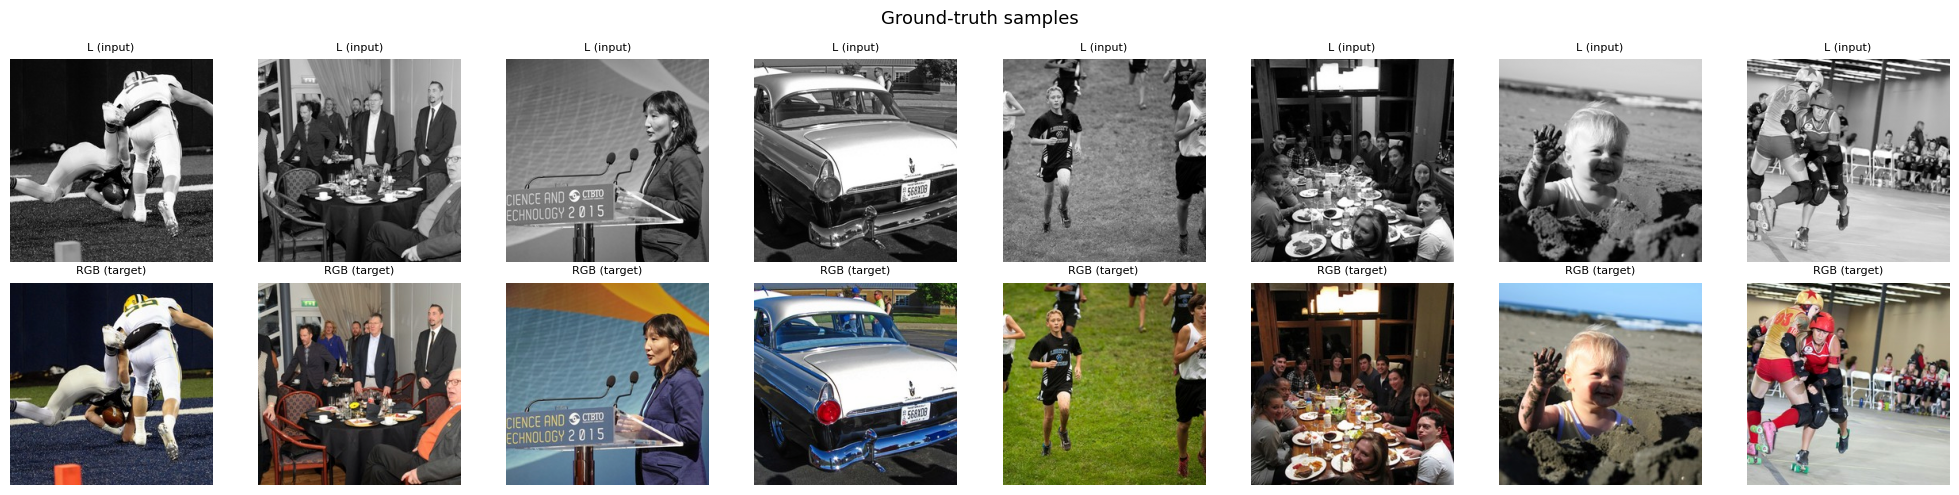

In [6]:
def show_samples(loader, n=8, title="Ground-truth samples"):
    l_batch, ab_batch = next(iter(loader))
    l_batch, ab_batch = l_batch[:n], ab_batch[:n]

    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5))
    fig.suptitle(title, fontsize=13)

    for i in range(n):
        # Row 0: grayscale L channel
        gray = (l_batch[i, 0].numpy() + 1.0) / 2.0  # [-1,1] -> [0,1]
        axes[0, i].imshow(gray, cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title("L (input)", fontsize=8)
        axes[0, i].axis("off")

        # Row 1: full RGB reconstruction from (L, ab)
        rgb = lab_to_rgb(l_batch[i], ab_batch[i])
        axes[1, i].imshow(rgb)
        axes[1, i].set_title("RGB (target)", fontsize=8)
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_loader)

## 4. Model

In [7]:
model = UNet(in_channels=1, out_channels=2).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total  |  {trainable:,} trainable")

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.randn(2, 1, 256, 256, device=DEVICE)
    out   = model(dummy)
    print(f"Input shape:  {dummy.shape}")
    print(f"Output shape: {out.shape}   (expected: (2, 2, 256, 256))")
    print(f"Output range: [{out.min():.3f}, {out.max():.3f}]  (expected: [-1, 1])")

Parameters: 16,656,066 total  |  16,656,066 trainable
Input shape:  torch.Size([2, 1, 256, 256])
Output shape: torch.Size([2, 2, 256, 256])   (expected: (2, 2, 256, 256))
Output range: [-1.000, 1.000]  (expected: [-1, 1])


## 5. Training

In [8]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"], betas=CFG["betas"])

# Linear warmup for CFG["lr_decay_start"] epochs, then cosine decay to 0
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG["epochs"] - CFG["lr_decay_start"],
    eta_min=1e-6,
)

In [9]:
def psnr(pred_ab: torch.Tensor, true_ab: torch.Tensor) -> float:
    """PSNR on ab channels denormalized to [-128, 128] (max range = 256)."""
    mse = F.mse_loss(pred_ab * 128.0, true_ab * 128.0).item()
    if mse == 0:
        return float("inf")
    return 20.0 * math.log10(256.0 / math.sqrt(mse))


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for l_batch, ab_batch in loader:
        l_batch  = l_batch.to(device)
        ab_batch = ab_batch.to(device)

        optimizer.zero_grad()
        pred_ab = model(l_batch)
        loss    = criterion(pred_ab, ab_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * l_batch.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss  = 0.0
    total_psnr  = 0.0
    for l_batch, ab_batch in loader:
        l_batch  = l_batch.to(device)
        ab_batch = ab_batch.to(device)

        pred_ab     = model(l_batch)
        total_loss += criterion(pred_ab, ab_batch).item() * l_batch.size(0)
        total_psnr += psnr(pred_ab.cpu(), ab_batch.cpu()) * l_batch.size(0)

    n = len(loader.dataset)
    return total_loss / n, total_psnr / n

In [ ]:
CFG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)

history = {"train_loss": [], "val_loss": [], "val_psnr": []}
best_val_loss = float("inf")

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss          = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_psnr  = eval_epoch(model, val_loader, criterion, DEVICE)

    # Step scheduler only after warm-up phase
    if epoch >= CFG["lr_decay_start"]:
        scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:3d}/{CFG['epochs']}  "
        f"train={train_loss:.4f}  val={val_loss:.4f}  "
        f"PSNR={val_psnr:.2f}dB  lr={lr_now:.2e}  ({elapsed:.0f}s)"
    )

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CFG["checkpoint_dir"] / "best.pth")

    # Periodic checkpoint
    if epoch % CFG["save_every"] == 0:
        torch.save(
            {"epoch": epoch, "model": model.state_dict(),
             "optimizer": optimizer.state_dict(), "history": history},
            CFG["checkpoint_dir"] / f"epoch_{epoch:03d}.pth",
        )

print(f"\nBest val loss: {best_val_loss:.4f}")

/Users/iquenavarro/Desktop/Insper/Insper AI/image-colorization/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x121e671a0>
Traceback (most recent call last):
  File "/Users/iquenavarro/Desktop/Insper/Insper AI/image-colorization/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/Users/iquenavarro/Desktop/Insper/Insper AI/image-colorization/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/p

KeyboardInterrupt: 

## 6. Training Curves

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train L1")
ax1.plot(epochs_range, history["val_loss"],   label="Val L1")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("L1 Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["val_psnr"], color="tab:green", label="Val PSNR")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("PSNR (dB)")
ax2.set_title("Validation PSNR (ab channels)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualize Colorization Results

Load the best checkpoint and run on the validation set.  
Each row: **Grayscale input → U-Net prediction → Ground truth**.

In [ ]:
# Load best model weights
model.load_state_dict(torch.load(CFG["checkpoint_dir"] / "best.pth", map_location=DEVICE))
model.eval()
print("Loaded best checkpoint.")

In [ ]:
@torch.no_grad()
def visualize_predictions(model, loader, device, n=8, title="U-Net colorization"):
    l_batch, ab_batch = next(iter(loader))
    l_batch, ab_batch = l_batch[:n].to(device), ab_batch[:n].to(device)

    pred_ab = model(l_batch).cpu()
    l_batch  = l_batch.cpu()
    ab_batch = ab_batch.cpu()

    fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8))
    fig.suptitle(title, fontsize=13)
    row_labels = ["Grayscale (input)", "Predicted (U-Net)", "Ground truth"]

    for i in range(n):
        gray = (l_batch[i, 0].numpy() + 1.0) / 2.0
        pred_rgb  = lab_to_rgb(l_batch[i], pred_ab[i])
        truth_rgb = lab_to_rgb(l_batch[i], ab_batch[i])

        axes[0, i].imshow(gray, cmap="gray", vmin=0, vmax=1)
        axes[1, i].imshow(pred_rgb)
        axes[2, i].imshow(truth_rgb)

        for row in range(3):
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].set_ylabel(row_labels[row], fontsize=9)

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, DEVICE)

## 8. Test-set Evaluation

In [ ]:
test_loss, test_psnr = eval_epoch(model, test_loader, criterion, DEVICE)
print(f"Test L1 loss : {test_loss:.4f}")
print(f"Test PSNR    : {test_psnr:.2f} dB")

## 9. Checkpoint Info

In [ ]:
# Resume training from a periodic checkpoint
#
# ckpt = torch.load(CFG["checkpoint_dir"] / "epoch_025.pth", map_location=DEVICE)
# model.load_state_dict(ckpt["model"])
# optimizer.load_state_dict(ckpt["optimizer"])
# history = ckpt["history"]
# start_epoch = ckpt["epoch"] + 1
print("Checkpoints saved to:", CFG["checkpoint_dir"])
print("  best.pth           — lowest val loss")
print("  epoch_XXX.pth      — full state (model + optimizer + history) every", CFG["save_every"], "epochs")